In [ ]:

import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import defaultdict
from sklearn.metrics import roc_curve, auc, precision_recall_curve, average_precision_score
watt_tsv  = "/mnt/sunxh/sunxh/project/hct116/wattmamod.hct116.genome.tsv"
tand_tsv  = "/mnt/sunxh/sunxh/project/hct116/TandemMod.hct116.genome.tsv"
m6a_csv   = "/mnt/sunxh/sunxh/project/hct116/m6anet_result/data.site_proba.csv"
gtf_path  = "/mnt/sunxh/sunxh/project/HEYA8/Homo_sapiens.GRCh38.91.gtf"
truth_path = "/mnt/sunxh/sunxh/project/hct116/HCT116.m6ACE.pos.sorted.bed"
universe_mode = "intersection"
seed = 1
cols = ["tid","tpos","chr","gpos","motif","pred","prob"]
key = ["chr","gpos"]
def _norm_chr(x):
    x = str(x)
    return x if x.startswith("chr") else "chr"+x

def genome_tsv_to_site(tsv_path: str) -> pd.DataFrame:
    df = pd.read_csv(tsv_path, sep="\t", header=None, names=cols)
    df["chr"]  = df["chr"].map(_norm_chr)
    df["gpos"] = df["gpos"].astype(int)
    df["prob"] = df["prob"].astype(float)
    site = (df.groupby(key, as_index=False)
              .agg(score=("prob","mean"),
                   cov=("prob","size")))
    return site
site_w = genome_tsv_to_site(watt_tsv)
site_t = genome_tsv_to_site(tand_tsv)
print("Watt sites:", site_w.shape)
print("Tand sites:", site_t.shape)
tid_re = re.compile(r'transcript_id "([^"]+)"')
exon_dict = defaultdict(list)
chr_dict = {}
strand_dict = {}
with open(gtf_path) as f:
    for line in f:
        if not line or line[0] == "#":
            continue
        it = line.rstrip("\n").split("\t")
        if len(it) < 9 or it[2] != "exon":
            continue
        chrom = _norm_chr(it[0])
        st = int(it[3]); ed = int(it[4]); strand = it[6]
        m = tid_re.search(it[8])
        if not m:
            continue
        tid = m.group(1)
        tid0 = tid.split(".")[0]
        for k in (tid, tid0):
            exon_dict[k].append((st, ed))
            chr_dict[k] = chrom
            strand_dict[k] = strand

for k in list(exon_dict.keys()):
    exon_dict[k].sort(key=lambda x: x[0])

def txpos_to_genome(tid, tx_pos_1based):
    use_tid = tid if tid in exon_dict else tid.split(".")[0]
    if use_tid not in exon_dict:
        return None
    exons  = exon_dict[use_tid]
    chrom  = chr_dict[use_tid]
    strand = strand_dict[use_tid]
    if strand == "+":
        s = 0
        for st, ed in exons:
            L = ed - st + 1
            if tx_pos_1based > s + L:
                s += L
            else:
                return chrom, int(st + (tx_pos_1based - s) - 1)
    return None
df_m6 = pd.read_csv(m6a_csv)
need = {"transcript_id","transcript_position","mod_ratio"}
miss = need - set(df_m6.columns)
if miss:
    raise ValueError(f"m6anet {miss}")
rows = []
skip = 0
for r in df_m6.itertuples(index=False):
    tid = getattr(r, "transcript_id")
    txp0 = int(getattr(r, "transcript_position"))
    score = float(getattr(r, "mod_ratio"))
    out = txpos_to_genome(tid, txp0 + 1)
    if out is None:
        skip += 1
        continue
    chrom, gpos = out
    rows.append((chrom, gpos, score))
    
df_m6_map = pd.DataFrame(rows, columns=["chr","gpos","score_raw"])
site_m = (df_m6_map.groupby(key, as_index=False).agg(score=("score_raw","mean"),cov=("score_raw","size")))

def load_truth_sites(path: str) -> pd.DataFrame:
    try:
        df = pd.read_csv(path, sep=None, engine="python", comment="#")
        if df.shape[1] >= 2:
            # chr 列
            chr_col = None
            for c in df.columns:
                if c.lower() in ("chr","chrom","chromosome","seqname"):
                    chr_col = c; break
            if chr_col is not None:
                # pos 列
                for c in df.columns:
                    if c.lower() in ("gpos","pos","position"):
                        out = pd.DataFrame({
                            "chr": df[chr_col].map(_norm_chr),
                            "gpos": df[c].astype(int)
                        })
                        return out.drop_duplicates()
                for c in df.columns:
                    if c.lower() == "start":
                        out = pd.DataFrame({
                            "chr": df[chr_col].map(_norm_chr),
                            "gpos": df[c].astype(int) + 1
                        })
                        return out.drop_duplicates()
    except Exception:
        pass

    bed = pd.read_csv(path, sep="\t", header=None, comment="#")
    if bed.shape[1] < 3:
        raise ValueError("truth 文件列数不足：需要 BED>=3 列 或 含 chr/pos 的表。")
    out = pd.DataFrame({
        "chr": bed.iloc[:,0].map(_norm_chr),
        "gpos": bed.iloc[:,1].astype(int) + 1
    })
    return out.drop_duplicates()

pos_df = load_truth_sites(truth_path)[key].drop_duplicates()
print("truth pos sites:", pos_df.shape)

def build_universe(mode: str) -> pd.DataFrame:
    if mode == "intersection":
        k_w = set(map(tuple, site_w[key].to_numpy()))
        k_t = set(map(tuple, site_t[key].to_numpy()))
        k_m = set(map(tuple, site_m[key].to_numpy()))
        ks = k_w & k_t & k_m
        uni = pd.DataFrame(list(ks), columns=key)
    elif mode == "union":
        uni = pd.concat([site_w[key], site_t[key], site_m[key]], ignore_index=True).drop_duplicates()
    elif mode == "watt":
        uni = site_w[key].drop_duplicates()
    elif mode == "tand":
        uni = site_t[key].drop_duplicates()
    elif mode == "m6anet":
        uni = site_m[key].drop_duplicates()
    else:
        raise ValueError("universe_mode  intersection/union/watt/tand/m6anet")
    return uni

universe_df = build_universe(universe_mode)
print("universe size:", universe_df.shape)
eval_df = universe_df.merge(pos_df.assign(y=1), on=key, how="left")
eval_df["y"] = eval_df["y"].fillna(0).astype(int)
pos_rate = eval_df["y"].mean()
print("pos rate in universe:", pos_rate)
def eval_tool(eval_base: pd.DataFrame, site_df: pd.DataFrame, name: str):
    df = eval_base.merge(site_df[key + ["score"]], on=key, how="left")
    miss = df["score"].isna().mean()
    if miss > 0:
        print(f"[{name}] missing score rate = {miss:.4f}")
    df = df.dropna(subset=["score"])

    y_true = df["y"].to_numpy(int)
    y_score = df["score"].to_numpy(float)

    fpr, tpr, _ = roc_curve(y_true, y_score)
    roc_auc = auc(fpr, tpr)

    prec, rec, _ = precision_recall_curve(y_true, y_score)
    ap = average_precision_score(y_true, y_score)

    print(f"{name} ROC AUC = {roc_auc:.6f}")
    print(f"{name} PR  AUC = {ap:.6f}")
    return fpr, tpr, roc_auc, rec, prec, ap

fpr_w, tpr_w, auc_w, rec_w, prec_w, ap_w = eval_tool(eval_df, site_w, "WattmaMod")
fpr_t, tpr_t, auc_t, rec_t, prec_t, ap_t = eval_tool(eval_df, site_t, "TandemMod")
fpr_m, tpr_m, auc_m, rec_m, prec_m, ap_m = eval_tool(eval_df, site_m, "m6anet")

rng = np.random.default_rng(seed)
s_r = rng.random(len(eval_df))
y_u = eval_df["y"].to_numpy(int)
fpr_r, tpr_r, _ = roc_curve(y_u, s_r)
auc_r = auc(fpr_r, tpr_r)
prec_r, rec_r, _ = precision_recall_curve(y_u, s_r)
ap_r = average_precision_score(y_u, s_r)
print("Random ROC AUC =", float(auc_r))
print("Random PR  AUC =", float(ap_r))
c_w = (122/255, 189/255, 255/255)
c_t = (191/255, 128/255, 255/255)
c_m = (255/255, 198/255, 26/255)
c_r = "gray"



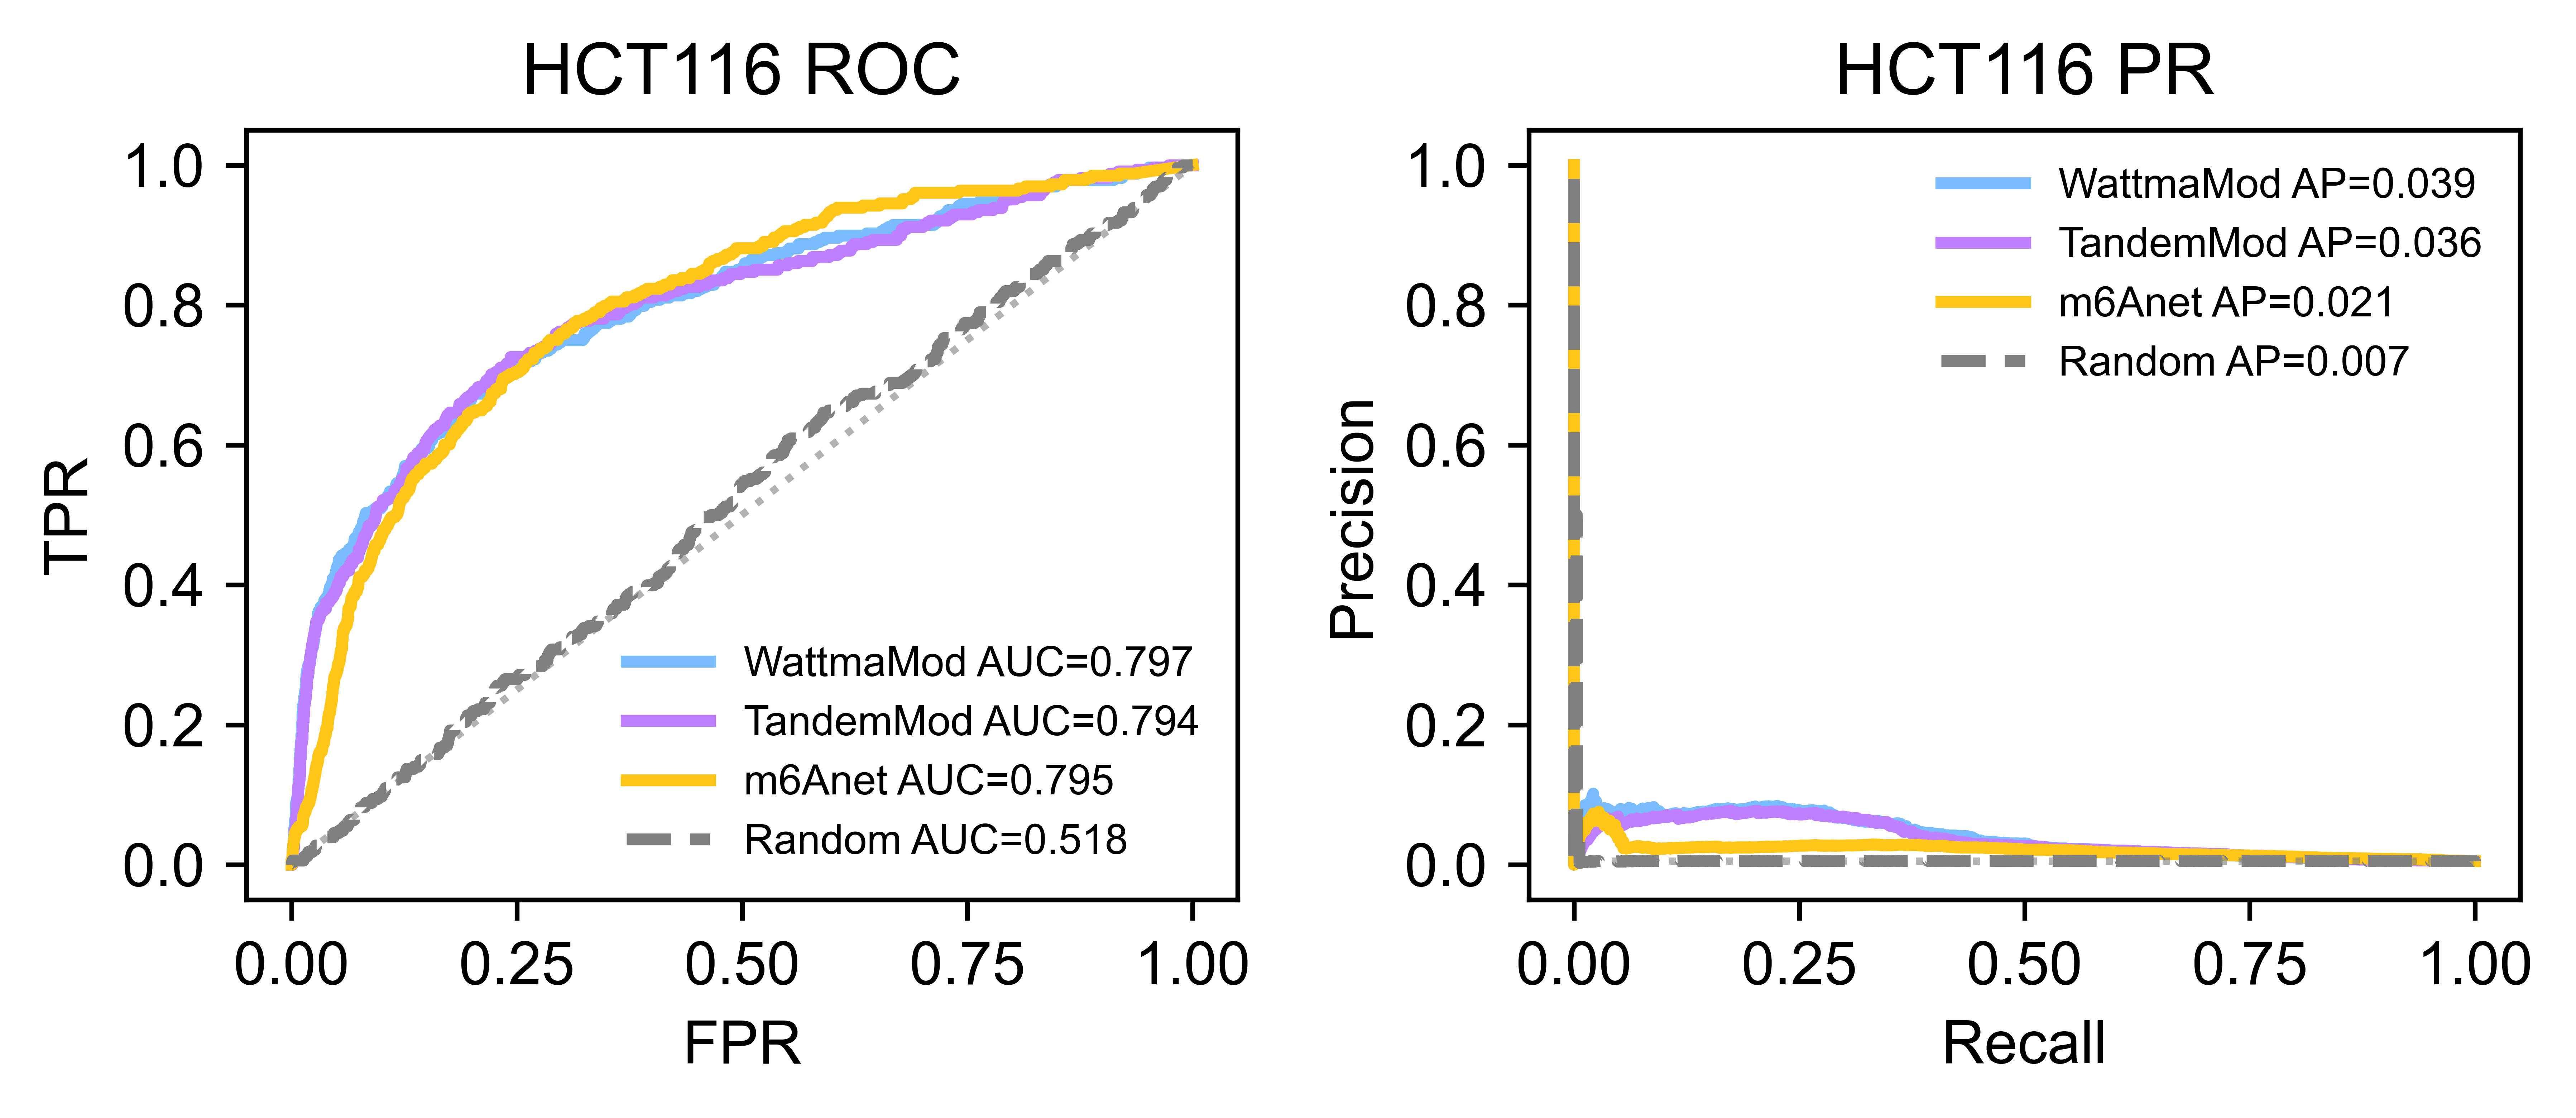

Saved: /mnt/sunxh/sunxh/project/hct116/HCT116_ROC_PR.pdf


In [ ]:
import matplotlib.pyplot as plt
plt.rcParams["font.sans-serif"] = ["Arial"]
plt.rcParams["axes.unicode_minus"] = False
plt.rcParams["pdf.fonttype"] = 42
plt.rcParams["ps.fonttype"]  = 42
out_pdf = "/mnt/sunxh/sunxh/project/hct116/HCT116_ROC_PR.pdf"
fig, axes = plt.subplots(1, 2, figsize=(6.1, 2.7), dpi=1200)
ax = axes[0]
ax.plot(fpr_w, tpr_w, label=f"WattmaMod AUC={auc_w:.3f}", color=c_w, linewidth=2)
ax.plot(fpr_t, tpr_t, label=f"TandemMod AUC={auc_t:.3f}", color=c_t, linewidth=2)
ax.plot(fpr_m, tpr_m, label=f"m6Anet AUC={auc_m:.3f}",   color=c_m, linewidth=2)
ax.plot(fpr_r, tpr_r, label=f"Random AUC={auc_r:.3f}",   color=c_r, linewidth=2, linestyle="--")
ax.plot([0,1],[0,1], linestyle=":", linewidth=1.2, color="gray", alpha=0.6)
ax.set_xlabel("FPR")
ax.set_ylabel("TPR")
ax.set_title("HCT116 ROC")
ax.legend(frameon=False, fontsize=7, loc="lower right")
ax = axes[1]
ax.plot(rec_w, prec_w, label=f"WattmaMod AP={ap_w:.3f}", color=c_w, linewidth=2)
ax.plot(rec_t, prec_t, label=f"TandemMod AP={ap_t:.3f}", color=c_t, linewidth=2)
ax.plot(rec_m, prec_m, label=f"m6Anet AP={ap_m:.3f}",   color=c_m, linewidth=2)
ax.plot(rec_r, prec_r, label=f"Random AP={ap_r:.3f}",   color=c_r, linewidth=2, linestyle="--")
ax.hlines(pos_rate, 0, 1, linestyles=":", linewidth=1.2, color="gray", alpha=0.6)
ax.set_xlabel("Recall")
ax.set_ylabel("Precision")
ax.set_title("HCT116 PR")
ax.legend(frameon=False, fontsize=7, loc="upper right")
plt.tight_layout(w_pad=1.2)
fig.savefig(out_pdf, format="pdf", bbox_inches="tight")
plt.show()
print("Saved:", out_pdf)


In [ ]:
import os
import pandas as pd
out_dir = "/mnt/sunxh/sunxh/project/hct116/site_pred"
os.makedirs(out_dir, exist_ok=True)
key = ["chr", "gpos"]
def save_site(site_df, name, out_dir):
    keep = [c for c in ["chr","gpos","score","cov"] if c in site_df.columns]
    if "chr" not in keep or "gpos" not in keep or "score" not in keep:
        raise ValueError(f"{name}  chr,gpos,score；当前列：{list(site_df.columns)}")
    df = site_df[keep].copy()
    df["chr"] = df["chr"].astype(str)
    df["gpos"] = df["gpos"].astype(int)
    df["score"] = df["score"].astype(float)
    if "cov" in df.columns:
        df["cov"] = pd.to_numeric(df["cov"], errors="coerce")
    df = df.drop_duplicates(subset=key).sort_values(key).reset_index(drop=True)
    tsv = os.path.join(out_dir, f"{name}.site.tsv")
    csv = os.path.join(out_dir, f"{name}.site.csv")
    df.to_csv(tsv, sep="\t", index=False)
    df.to_csv(csv, index=False)
    print(f"[save] {name}: {df.shape} -> {tsv}")
    return df
save_site(site_w,     "wattmamod",   out_dir)
save_site(site_t,     "tandemmod",   out_dir)
save_site(site_m, "m6anet", out_dir)


[save] wattmamod: (920237, 4) -> /mnt/sunxh/sunxh/project/hct116/site_pred/wattmamod.site.tsv
[save] tandemmod: (920237, 4) -> /mnt/sunxh/sunxh/project/hct116/site_pred/tandemmod.site.tsv
[save] m6anet: (66281, 4) -> /mnt/sunxh/sunxh/project/hct116/site_pred/m6anet.site.tsv


,chr,gpos,score,cov
0,chr1,629746,0.030500,1
1,chr1,629772,0.192161,1
2,chr1,629785,0.296286,1
3,chr1,629885,0.030000,1
4,chr1,629892,0.202692,1
...,...,...,...,...
66276,chrX,155942310,0.089706,1
66277,chrX,155942342,0.301103,1
66278,chrX,155942554,0.104522,1
66279,chrX,155942778,0.067778,1
